In [1]:
!pip install simpy scikit-learn pandas numpy matplotlib seaborn

In [2]:
import simpy
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

In [3]:
def queue_simulation(arrival_rate, service_rate, capacity, sim_time=1000):
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=capacity)

    wait_times = []

    def customer(env):
        arrival_time = env.now

        with server.request() as request:
            yield request
            wait = env.now - arrival_time
            wait_times.append(wait)

            service_time = np.random.exponential(1/service_rate)
            yield env.timeout(service_time)

    def arrival_process(env):
        while True:
            inter_arrival = np.random.exponential(1/arrival_rate)
            yield env.timeout(inter_arrival)
            env.process(customer(env))

    env.process(arrival_process(env))
    env.run(until=sim_time)

    return np.mean(wait_times) if wait_times else 0

In [4]:
# Lower and Upper bounds

arrival_rate_bounds = (0.5, 5.0)      # customers per unit time
service_rate_bounds = (0.5, 6.0)      # service speed
capacity_bounds = (1, 3)              # number of servers
simulation_time = 1000

In [5]:
num_simulations = 1000

data = []

for _ in range(num_simulations):
    arrival_rate = random.uniform(*arrival_rate_bounds)
    service_rate = random.uniform(*service_rate_bounds)
    capacity = random.randint(*capacity_bounds)

    avg_wait = queue_simulation(arrival_rate, service_rate, capacity, simulation_time)

    data.append([arrival_rate, service_rate, capacity, avg_wait])

df = pd.DataFrame(data, columns=[
    "arrival_rate",
    "service_rate",
    "capacity",
    "avg_wait_time"
])

df.head()

,arrival_rate,service_rate,capacity,avg_wait_time
0,3.085577,2.556564,2,0.198674
1,1.382804,2.168458,3,0.009360
2,2.959015,3.850899,3,0.003184
3,4.208727,4.154404,2,0.085672
4,3.624330,5.343841,3,0.003672


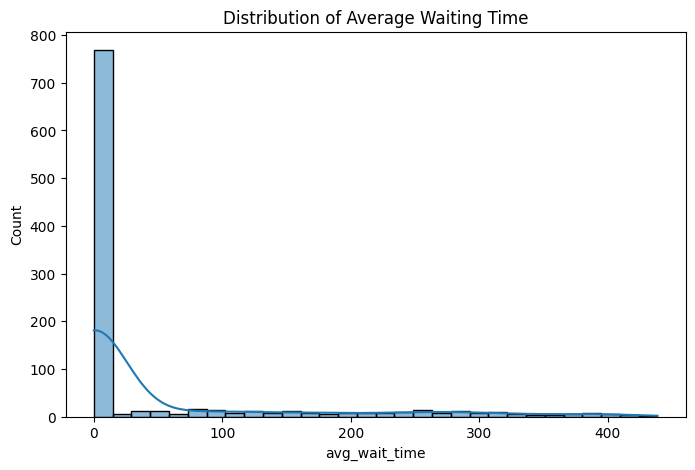

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["avg_wait_time"], bins=30, kde=True)
plt.title("Distribution of Average Waiting Time")
plt.show()

In [8]:
X = df.drop("avg_wait_time", axis=1)
y = df["avg_wait_time"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,56.472741,70.173288,0.492847
1,Decision Tree,9.672348,24.469092,0.938336
2,Random Forest,6.594796,14.945537,0.976995
3,Gradient Boosting,16.814281,27.228991,0.923641
4,KNN,5.067438,12.377125,0.984223
5,SVR,39.408946,87.913329,0.204015


In [10]:
results_df.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
4,KNN,5.067438,12.377125,0.984223
2,Random Forest,6.594796,14.945537,0.976995
1,Decision Tree,9.672348,24.469092,0.938336
3,Gradient Boosting,16.814281,27.228991,0.923641
0,Linear Regression,56.472741,70.173288,0.492847
5,SVR,39.408946,87.913329,0.204015


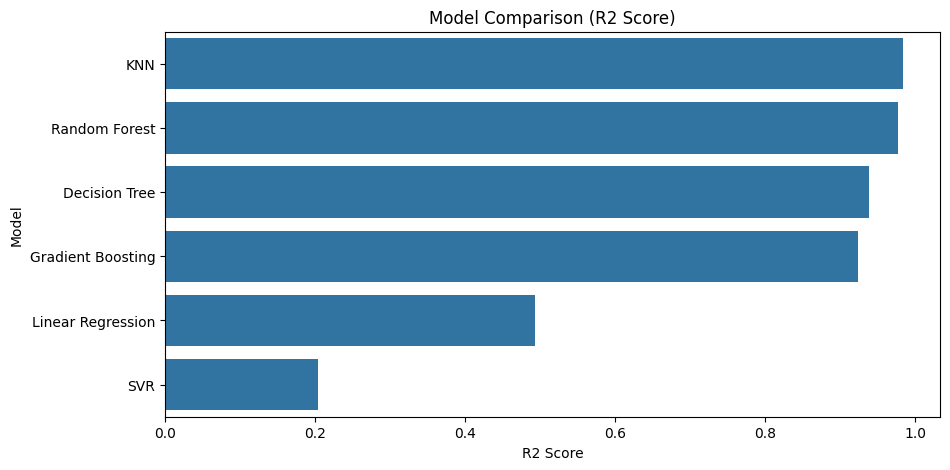

In [11]:
plt.figure(figsize=(10,5))
sns.barplot(x="R2 Score", y="Model", data=results_df.sort_values("R2 Score", ascending=False))
plt.title("Model Comparison (R2 Score)")
plt.show()